# 06 — Results Review

**Purpose:** Final review of flagged accounts — the analyst-facing notebook. This is what an AML analyst would open to understand which accounts were flagged and why.

This notebook is different from the others — it's less about validating the model and more about understanding the output as a human reviewer would. The questions we answer here:

- Which accounts are at the top of the anomaly list?
- What specific behaviors drove their scores? (Ranked feature contributions)
- What does the plain-English narrative say about each account?
- Did we catch the injected anomalies? Which patterns were hardest to detect?
- What do the supporting trades look like for the top-flagged accounts?

Run notebooks 01–05 first to generate all inputs.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))

from aml_anomaly.reporting.flags import generate_narrative, get_ranked_features

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

DATA_DIR    = Path("../data")
MODELS_DIR  = Path("../models")
OUTPUTS_DIR = Path("../outputs")

In [2]:
import json

scores    = pd.read_csv(OUTPUTS_DIR / "anomaly_scores.csv")
accounts  = pd.read_csv(DATA_DIR / "raw" / "accounts.csv")
trades    = pd.read_csv(DATA_DIR / "holdout" / "new_trades.csv", parse_dates=["trade_date"])
features  = pd.read_csv(DATA_DIR / "features" / "feature_matrix.csv")
injected  = pd.read_csv(DATA_DIR / "raw" / "injected_anomalies.csv")

with open(MODELS_DIR / "population_stats.json") as f:
    population_stats = json.load(f)

scores["is_injected"] = scores["account_id"].isin(injected["account_id"])
flagged = scores[scores["anomaly_flag"] == 1].sort_values("anomaly_rank")

print(f"Total accounts scored: {len(scores):,}")
print(f"Flagged accounts:      {len(flagged):,}")
print(f"Injected anomalies in flagged list: {flagged['is_injected'].sum()}")

Total accounts scored: 2,000
Flagged accounts:      80
Injected anomalies in flagged list: 27


## 1. Anomaly score overview

A histogram of all anomaly scores with the flagging threshold marked. We expect to see the population bunched near zero with a thin high-scoring tail.

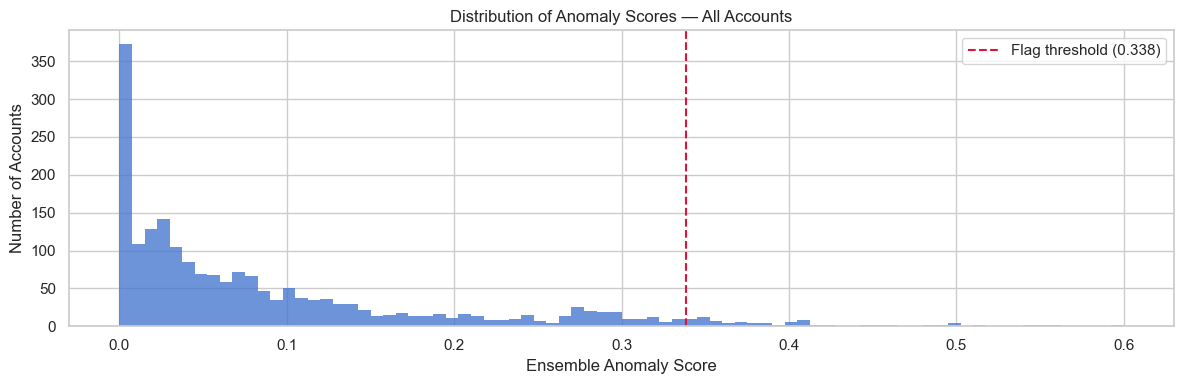

In [3]:
threshold = scores[scores["anomaly_flag"] == 1]["anomaly_score"].min()

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(scores["anomaly_score"], bins=80, edgecolor="none", alpha=0.8)
ax.axvline(threshold, color="crimson", linestyle="--", label=f"Flag threshold ({threshold:.3f})")
ax.set_xlabel("Ensemble Anomaly Score")
ax.set_ylabel("Number of Accounts")
ax.set_title("Distribution of Anomaly Scores — All Accounts")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Top 20 flagged accounts

The accounts an analyst would review first. Red rows are injected anomalies — confirming the model is ranking them at the top.

In [4]:
top20 = flagged.head(20).merge(
    accounts[["account_id", "customer_name", "account_type", "risk_tier", "is_pep", "state"]],
    on="account_id"
).merge(
    injected[["account_id", "anomaly_pattern"]].rename(columns={"anomaly_pattern": "injected_pattern"}),
    on="account_id", how="left"
)

display_cols = ["anomaly_rank", "account_id", "customer_name", "account_type",
                "risk_tier", "anomaly_score", "is_pep", "injected_pattern"]

top20[display_cols].style.apply(
    lambda row: ["background-color: #ffe5e5" if row["injected_pattern"] is not None else "" for _ in row],
    axis=1
)

,anomaly_rank,account_id,customer_name,account_type,risk_tier,anomaly_score,is_pep,injected_pattern
0,1,ACC-00329,Jeremy Sampson,Retail,2,0.600000,False,nan
1,2,ACC-00713,Timothy Edwards,Institutional,5,0.560352,False,nan
2,3,ACC-01385,Jacqueline Dickerson,Broker-Dealer,1,0.550687,False,nan
3,4,ACC-01492,Anne Hardy,Institutional,2,0.540440,False,smurfing
4,5,ACC-00925,Danielle Murray,Retail,2,0.517184,False,smurfing
5,6,ACC-01890,Kimberly Norton,Retail,2,0.501185,False,smurfing
6,7,ACC-00153,Denise Jones,Retail,2,0.501104,False,smurfing
7,8,ACC-00722,Raymond Johnson,Retail,1,0.496926,False,smurfing
8,9,ACC-01538,Wanda Ramos,Institutional,2,0.496223,False,smurfing
9,10,ACC-00151,David Wright,Institutional,2,0.494603,False,nan


## 3. Plain-English narrative for a flagged account

This is the analyst-facing explanation — no variable names, no statistics jargon. Just a clear description of what the account was doing.

In [5]:
# Change this to any account_id from the top flagged list above
example_account = flagged.iloc[0]["account_id"]

narrative = generate_narrative(example_account, features, scores, population_stats)

print(f"Account: {example_account}")
print(f"Anomaly Rank: {scores.loc[scores['account_id'] == example_account, 'anomaly_rank'].values[0]}")
print()
print("Narrative:")
print("-" * 60)
print(narrative)

Account: ACC-00329
Anomaly Rank: 1

Narrative:
------------------------------------------------------------
This account's 100% of trade value was in micro-cap stocks, and 100% of trade value was directed at thinly-traded, illiquid stocks. This account ranks #1 out of all scored accounts by anomaly score.


## 4. Ranked feature contributions

The data-scientist-facing view: which features drove the score, how far from the population mean, and what was the account's actual value.

In [6]:
feature_table = get_ranked_features(example_account, features, scores, population_stats)
print(feature_table.to_string(index=False))

                       feature                               label  account_value  population_mean  deviation_sigma
           micro_cap_trade_pct     % of trades in micro-cap stocks            1.0           0.0281             6.25
      illiquid_stock_trade_pct % of trades in thinly-traded stocks            1.0           0.0448             4.87
              account_age_days                  Account age (days)          611.0        2898.7805            -1.58
  top_ticker_concentration_pct       % of activity in single stock            1.0           0.3770             1.40
top_3_ticker_concentration_pct       % of activity in top 3 stocks            1.0           0.4309             1.16


## 5. Supporting trades for the flagged account

The 20 most relevant individual transactions — the actual trades that drove the anomalous features.

In [7]:
account_trades = trades[trades["account_id"] == example_account].sort_values("trade_date")

display_cols = [
    "trade_id", "trade_date", "trade_time", "ticker", "trade_direction",
    "quantity", "trade_value_usd", "counterparty_account_id", "is_off_hours", "is_round_value"
]
print(f"Total trades for {example_account}: {len(account_trades)}")
account_trades[display_cols].head(20)

Total trades for ACC-00329: 3


,trade_id,trade_date,trade_time,ticker,trade_direction,quantity,trade_value_usd,counterparty_account_id,is_off_hours,is_round_value
21716,TRD-0045940,2024-11-01,14:42:29,DKY,BUY,29,56.55,NaN,False,False
8833,TRD-0059454,2025-06-18,13:15:01,FAD,SELL,10,25.10,NaN,False,False
21041,TRD-0005198,2026-05-06,12:18:33,NKOG,BUY,54298,2141513.12,NaN,False,True


## 6. Injected anomaly validation summary

The final validation: how many of the known injected anomalies did we catch, broken down by pattern? This is the qualitative benchmark for the whole system.

In [8]:
validation = scores.merge(injected[["account_id", "anomaly_pattern"]], on="account_id", how="right")

summary = validation.groupby("anomaly_pattern").agg(
    total=("account_id", "count"),
    flagged=("anomaly_flag", "sum"),
    avg_score=("anomaly_score", "mean"),
    avg_rank=("anomaly_rank", "mean"),
).reset_index()
summary["recall"] = (summary["flagged"] / summary["total"]).map("{:.0%}".format)

print("Injected Anomaly Detection Summary:")
print(summary.to_string(index=False))

overall = validation["anomaly_flag"].mean()
print(f"\nOverall recall: {overall:.1%}")

Injected Anomaly Detection Summary:
       anomaly_pattern  total  flagged  avg_score   avg_rank recall
illiquid_concentration     15        0   0.286505 167.866667     0%
  off_hours_clustering     15        8   0.352338  91.800000    53%
              smurfing     15       13   0.428416  35.266667    87%
        velocity_spike     15        0   0.181316 356.066667     0%
          wash_trading     15        6   0.335949  96.533333    40%

Overall recall: 36.0%


## 7. Browse multiple flagged accounts

Interactive loop to view narratives and feature tables for any set of accounts.

In [9]:
# Change n_accounts to review more or fewer accounts
n_accounts = 5

for _, row in flagged.head(n_accounts).iterrows():
    acct = row["account_id"]
    pattern = injected.loc[injected["account_id"] == acct, "anomaly_pattern"]
    pattern_str = f" [INJECTED: {pattern.values[0]}]" if len(pattern) > 0 else ""

    print("=" * 70)
    print(f"Rank #{int(row['anomaly_rank'])} - {acct}{pattern_str}")
    print(f"Score: {row['anomaly_score']:.4f}")
    print("Narrative:")
    print(generate_narrative(acct, features, scores, population_stats))
    print()
    print("Top features:")
    print(get_ranked_features(acct, features, scores, population_stats).head(5).to_string(index=False))
    print()

Rank #1 - ACC-00329
Score: 0.6000
Narrative:
This account's 100% of trade value was in micro-cap stocks, and 100% of trade value was directed at thinly-traded, illiquid stocks. This account ranks #1 out of all scored accounts by anomaly score.

Top features:
                       feature                               label  account_value  population_mean  deviation_sigma
           micro_cap_trade_pct     % of trades in micro-cap stocks            1.0           0.0281             6.25
      illiquid_stock_trade_pct % of trades in thinly-traded stocks            1.0           0.0448             4.87
              account_age_days                  Account age (days)          611.0        2898.7805            -1.58
  top_ticker_concentration_pct       % of activity in single stock            1.0           0.3770             1.40
top_3_ticker_concentration_pct       % of activity in top 3 stocks            1.0           0.4309             1.16

Rank #2 - ACC-00713
Score: 0.5604
Narrative: